In [1]:
# Importamos las librerías principales

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# Cargar archivo CSV desde la computadora

from google.colab import files

archivo = files.upload()

Saving dataset_segmentacion_clientes.csv to dataset_segmentacion_clientes.csv


In [3]:
# Leer automáticamente el archivo subido

nombre_archivo = list(archivo.keys())[0]

df = pd.read_csv(nombre_archivo)

# Mostrar las primeras filas
df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522


In [4]:
# Ver las columnas disponibles en el dataset

df.columns

Index(['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min',
       'discount_sensitivity', 'returns_rate', 'noise_gauss', 'noise_uniform'],
      dtype='object')

In [6]:
columnas_esperadas = [
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]

columnas_esperadas

['purchase_freq_month',
 'avg_basket_usd',
 'time_on_site_min',
 'discount_sensitivity',
 'returns_rate']

In [7]:
# Verificar si están todas las columnas necesarias

columnas_esperadas = ['purchase_freq_month', 'avg_basket_usd', 'time_on_site_min', 'discount_sensitivity', 'returns_rate', 'noise_gauss', 'noise_uniform']

for columna in columnas_esperadas:
    if columna in df.columns:
        print(columna, 'OK')
    else:
        print(columna, 'NO ENCONTRADA')

purchase_freq_month OK
avg_basket_usd OK
time_on_site_min OK
discount_sensitivity OK
returns_rate OK
noise_gauss OK
noise_uniform OK


In [8]:
# Verificar si están todas las columnas necesarias

for columna in columnas_esperadas:
    if columna in df.columns:
        print(columna, 'OK')
    else:
        print(columna, 'NO ENCONTRADA')

purchase_freq_month OK
avg_basket_usd OK
time_on_site_min OK
discount_sensitivity OK
returns_rate OK
noise_gauss OK
noise_uniform OK


In [9]:
# Ver cantidad de filas y columnas

df.shape

(700, 7)

In [10]:
# Ver información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   purchase_freq_month   700 non-null    float64
 1   avg_basket_usd        700 non-null    float64
 2   time_on_site_min      700 non-null    float64
 3   discount_sensitivity  700 non-null    float64
 4   returns_rate          700 non-null    float64
 5   noise_gauss           700 non-null    float64
 6   noise_uniform         700 non-null    float64
dtypes: float64(7)
memory usage: 38.4 KB


In [11]:
# Ver resumen estadístico de las variables numéricas

df.describe()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform
count,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000,700.000000
mean,5.875724,248.173491,16.784799,0.425083,0.337194,0.023814,-0.010523
std,4.471079,154.904372,12.914111,0.431467,0.356623,1.009325,1.679810
min,0.100000,86.994100,3.163206,0.000000,0.000000,-3.566175,-2.993585
25%,2.278418,90.766945,6.603950,0.000000,0.000000,-0.654168,-1.424864
50%,4.134580,180.223799,9.974407,0.296475,0.165559,0.076845,0.013148
75%,11.214919,449.719033,34.341360,1.000000,0.800000,0.728304,1.407124
max,14.603388,452.973583,38.348156,1.000000,0.800000,2.863317,2.995020


In [12]:
# Revisamos si hay valores faltantes en cada columna

df.isnull().sum()

,0
purchase_freq_month,0
avg_basket_usd,0
time_on_site_min,0
discount_sensitivity,0
returns_rate,0
noise_gauss,0
noise_uniform,0


In [13]:
# Seleccionamos las variables indicadas en nuestrav consigna

variables_kmeans = [
    'purchase_freq_month',
    'avg_basket_usd',
    'time_on_site_min',
    'discount_sensitivity',
    'returns_rate'
]

X = df[variables_kmeans]

X.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,11.152508,181.300834,33.564036,1.000000,0.800000
1,12.053451,178.637272,35.432081,0.784974,0.000000
2,2.203006,450.185298,7.030757,0.898297,0.000000
3,4.233314,89.006342,10.834453,0.000000,0.800000
4,1.716799,449.773982,7.254548,0.000000,0.003279


In [14]:
# Escalamos las variables para que todas tengan un peso comparable

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [15]:
# Convertimos los datos escalados en un DataFrame

X_scaled_df = pd.DataFrame(X_scaled, columns=variables_kmeans)

X_scaled_df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
0,1.181048,-0.432012,1.300224,1.333423,1.298671
1,1.382696,-0.449219,1.444979,0.834706,-0.946196
2,-0.822026,1.305039,-0.755841,1.097540,-0.946196
3,-0.367604,-1.028253,-0.461093,-0.985910,1.298671
4,-0.930849,1.302382,-0.738500,-0.985910,-0.936996


In [16]:
# Probamos distintos valores de k para aplicar el método del codo

inercias = []
valores_k = range(2, 7)

for k in valores_k:
    modelo_kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo_kmeans.fit(X_scaled)
    inercias.append(modelo_kmeans.inertia_)

In [17]:
# Creamos una tabla para ver la inercia de cada valor de k

resultados_codo = pd.DataFrame({
    'k': list(valores_k),
    'inercia': inercias
})

resultados_codo

,k,inercia
0,2,2088.881213
1,3,1408.702436
2,4,1173.438207
3,5,997.742488
4,6,762.466098


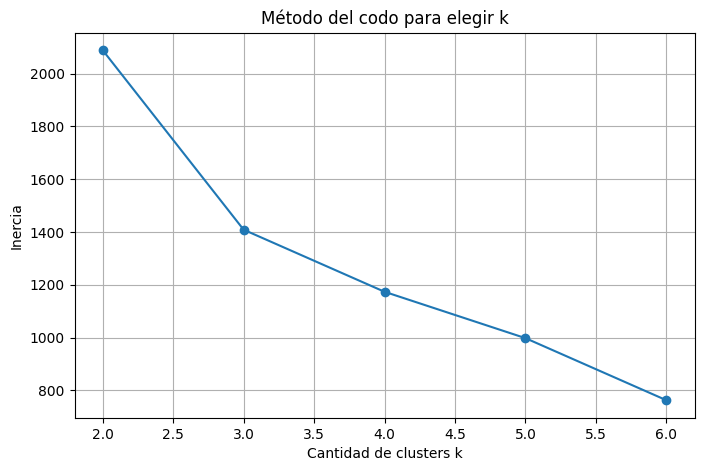

In [18]:
# Graficamos el método del codo

plt.figure(figsize=(8, 5))

plt.plot(valores_k, inercias, marker='o')

plt.xlabel('Cantidad de clusters k')
plt.ylabel('Inercia')
plt.title('Método del codo para elegir k')

plt.grid(True)
plt.show()

In [19]:
# Elegimos k = 3 según el método del codo

k_elegido = 3

modelo_final = KMeans(
    n_clusters=k_elegido,
    random_state=42,
    n_init=10
)

modelo_final.fit(X_scaled)

KMeans(n_clusters=3, n_init=10, random_state=42)

In [20]:
# Agregamos la etiqueta de cluster al dataset original

df['cluster'] = modelo_final.labels_

df.head()

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,noise_gauss,noise_uniform,cluster
0,11.152508,181.300834,33.564036,1.000000,0.800000,-1.806578,-2.516905,0
1,12.053451,178.637272,35.432081,0.784974,0.000000,0.645129,2.115460,0
2,2.203006,450.185298,7.030757,0.898297,0.000000,-0.047406,-0.724173,1
3,4.233314,89.006342,10.834453,0.000000,0.800000,0.901700,-2.974026,2
4,1.716799,449.773982,7.254548,0.000000,0.003279,0.386013,2.424522,1


In [21]:
# Cantidad de clientes por cluster

df['cluster'].value_counts()

,count
cluster,
1,250
0,230
2,220


In [22]:
# Promedio de cada variable según cluster

perfil_clusters = df.groupby('cluster')[variables_kmeans].mean()

perfil_clusters

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.961153,179.999315,35.022131,0.541539,0.332461
1,1.846908,450.123746,5.973739,0.358088,0.375371
2,4.091883,89.957567,10.003793,0.379465,0.298761


In [23]:
# Redondeamos los valores para facilitar la interpretación

perfil_clusters_redondeado = perfil_clusters.round(2)

perfil_clusters_redondeado

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,11.96,180.00,35.02,0.54,0.33
1,1.85,450.12,5.97,0.36,0.38
2,4.09,89.96,10.00,0.38,0.30


In [24]:
# Cantidad de clientes en cada cluster

cantidad_por_cluster = df['cluster'].value_counts().sort_index()

cantidad_por_cluster

,count
cluster,
0,230
1,250
2,220


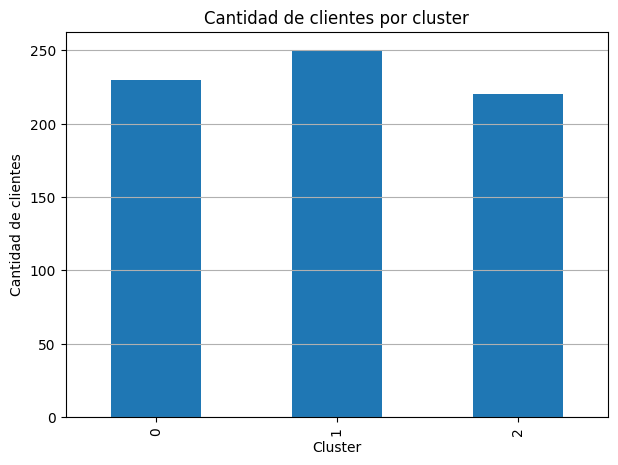

In [25]:
# Gráfico de cantidad de clientes por cluster

plt.figure(figsize=(7, 5))

cantidad_por_cluster.plot(kind='bar')

plt.xlabel('Cluster')
plt.ylabel('Cantidad de clientes')
plt.title('Cantidad de clientes por cluster')

plt.grid(axis='y')
plt.show()

In [26]:
# Creamos un DataFrame con los datos escalados y el cluster asignado

X_scaled_df['cluster'] = df['cluster']

# Promedio de variables escaladas por cluster

perfil_clusters_escalado = X_scaled_df.groupby('cluster').mean()

perfil_clusters_escalado.round(2)

,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate
cluster,,,,,
0,1.36,-0.44,1.41,0.27,-0.01
1,-0.90,1.30,-0.84,-0.16,0.11
2,-0.40,-1.02,-0.53,-0.11,-0.11


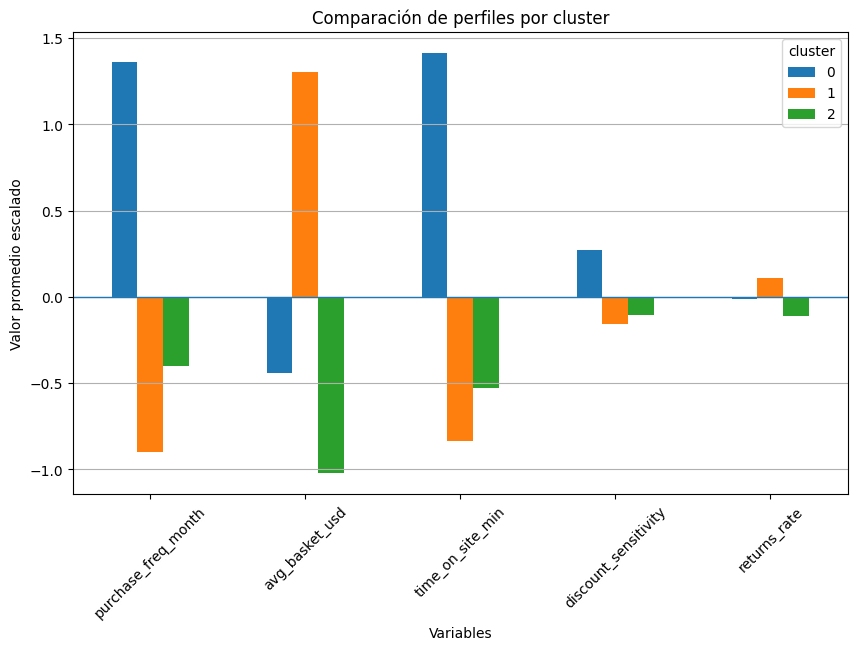

In [27]:
# Gráfico comparativo de perfiles por cluster

perfil_clusters_escalado.T.plot(kind='bar', figsize=(10, 6))

plt.xlabel('Variables')
plt.ylabel('Valor promedio escalado')
plt.title('Comparación de perfiles por cluster')

plt.axhline(0, linewidth=1)
plt.grid(axis='y')
plt.xticks(rotation=45)

plt.show()

Cluster 0
Tiene la mayor frecuencia de compra mensual, con un promedio de 11.96 compras. También tiene un ticket de 180 dólares, mucho tiempo en el sitio y la mayor sensibilidad a descuentos. Es un grupo de clientes frecuentes, activos y atentos a promociones. Puede ser un segmento útil para campañas de descuentos, beneficios por recurrencia o programas de fidelización.

Cluster 1
Tiene baja frecuencia de compra, pero el ticket promedio más alto, con 450.12 dólares. Pasa poco tiempo en el sitio y no parece depender tanto de los descuentos. Tiene la tasa de devoluciones más alta. Es un grupo de compradores esporádicos, pero de alto valor. Puede trabajarse con estrategias premium, productos de mayor valor y mejora de posventa para reducir devoluciones.

Cluster 2
Tiene frecuencia intermedia baja, ticket promedio bajo y tiempo moderado en el sitio. La sensibilidad a descuentos es baja media y la tasa de devoluciones es la menor de los tres grupos. Puede representar clientes ocasionales de bajo gasto, con potencial para acciones de reactivación o promociones simples.

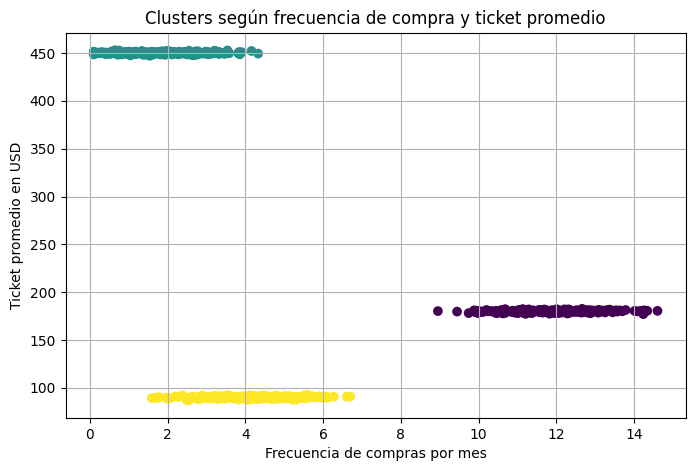

In [28]:
# Gráfico de frecuencia de compra y ticket promedio según cluster

plt.figure(figsize=(8, 5))

plt.scatter(
    df['purchase_freq_month'],
    df['avg_basket_usd'],
    c=df['cluster']
)

plt.xlabel('Frecuencia de compras por mes')
plt.ylabel('Ticket promedio en USD')
plt.title('Clusters según frecuencia de compra y ticket promedio')

plt.grid(True)
plt.show()

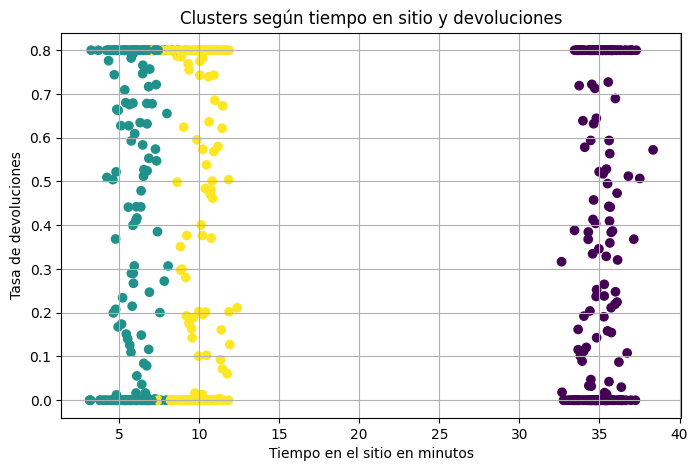

In [29]:
# Gráfico de tiempo en sitio y tasa de devoluciones según cluster

plt.figure(figsize=(8, 5))

plt.scatter(
    df['time_on_site_min'],
    df['returns_rate'],
    c=df['cluster']
)

plt.xlabel('Tiempo en el sitio en minutos')
plt.ylabel('Tasa de devoluciones')
plt.title('Clusters según tiempo en sitio y devoluciones')

plt.grid(True)
plt.show()

In [30]:
# Creamos una tabla de interpretación de los clusters

interpretacion_clusters = pd.DataFrame({
    'cluster': [0, 1, 2],
    'perfil': [
        'Clientes frecuentes, activos y sensibles a descuentos',
        'Clientes esporádicos, de alto ticket y menor sensibilidad a descuentos',
        'Clientes ocasionales, de bajo ticket y menor tasa de devoluciones'
    ],
    'posible_estrategia': [
        'Promociones, beneficios por recurrencia y fidelización',
        'Upselling premium, atención personalizada y mejora de posventa',
        'Reactivación, ofertas simples y comunicación segmentada'
    ]
})

interpretacion_clusters

,cluster,perfil,posible_estrategia
0,0,"Clientes frecuentes, activos y sensibles a des...","Promociones, beneficios por recurrencia y fide..."
1,1,"Clientes esporádicos, de alto ticket y menor s...","Upselling premium, atención personalizada y me..."
2,2,"Clientes ocasionales, de bajo ticket y menor t...","Reactivación, ofertas simples y comunicación s..."


In [31]:
# Unimos los promedios de cada cluster con la interpretación

tabla_final_clusters = perfil_clusters_redondeado.reset_index().merge(
    interpretacion_clusters,
    on='cluster'
)

tabla_final_clusters

,cluster,purchase_freq_month,avg_basket_usd,time_on_site_min,discount_sensitivity,returns_rate,perfil,posible_estrategia
0,0,11.96,180.00,35.02,0.54,0.33,"Clientes frecuentes, activos y sensibles a des...","Promociones, beneficios por recurrencia y fide..."
1,1,1.85,450.12,5.97,0.36,0.38,"Clientes esporádicos, de alto ticket y menor s...","Upselling premium, atención personalizada y me..."
2,2,4.09,89.96,10.00,0.38,0.30,"Clientes ocasionales, de bajo ticket y menor t...","Reactivación, ofertas simples y comunicación s..."


Análisis del método del codo

Se aplicó K-Means probando valores de k entre 2 y 6, tal como indica la consigna. Para comparar los resultados de utilizó la inercia, que permite observar qué tan compactos quedan los grupos formados.

En el gráfico del método del codo se observa una caída fuerte de la inercia entre k igual a 2 y k igual a 3. A partir de ese punto, la inercia continúa bajando, pero de manera más gradual. Por ese motivo se seleccionó k igual a 3 como una cantidad razonable de clusters.

Esta elección permite segmentar a los clientes en tres grupos diferenciados sin generar una división excesiva.

Interpretación de los clusters

A partir del análisis de los centroides, se identificaron tres perfiles de clientes.

El Cluster 0 reúne clientes con alta frecuencia de compra, ticket promedio medio, mayor tiempo de permanencia en el sitio y mayor sensibilidad a descuentos. Este grupo puede interpretarse como clientes frecuentes y activos, adecuados para acciones de fidelización, promociones recurrentes y beneficios por compra frecuente.

El Cluster 1 agrupa clientes con baja frecuencia de compra, pero con el ticket promedio más alto. También presenta menor tiempo de permanencia en el sitio y una sensibilidad a descuentos más baja. Este segmento puede representar clientes esporádicos de alto valor, por lo que podrían trabajarse estrategias de productos premium, upselling y mejora de la experiencia posterior a la compra.

El Cluster 2 presenta una frecuencia de compra intermedia baja, menor ticket promedio, tiempo de permanencia moderado y la menor tasa de devoluciones. Puede interpretarse como un grupo de clientes ocasionales de bajo gasto, con potencial para acciones de reactivación y comunicación segmentada.

En sintesis, K-Means permitió detectar segmentos latentes de clientes a partir de variables de comportamiento, sin utilizar etiquetas previas. El análisis de los centroides permitió describir perfiles útiles para pensar acciones comerciales diferenciadas.